# Bitcoin Historical Data Summary

This dataset offers minute-by-minute historical market data for Bitcoin, sourced from select exchanges. The primary file, `btcusd_1-min_data.csv`, is approximately 350 MB and contains hundreds of thousands of data points covering a broad price range and time period. Key columns typically include:[1][2][3]

- Timestamp (UTC)
- Open price
- High price
- Low price
- Close price
- Volume traded

The dataset enables granular analysis and modeling of Bitcoin's market behavior, making it suitable for time series forecasting and machine learning applications.[4][5]

## Use Cases

- Price prediction/forecasting
- Volatility analysis
- Trading strategy backtesting
- Anomaly detection

***

# Steps for RNN and ARIMA Prediction

## Data Preparation

- Load the CSV into a pandas DataFrame, parse timestamps, and sort chronologically.[4]
- Handle missing data by interpolation or removal.
- Optionally, resample to longer intervals (e.g., hourly/daily) for less granular modeling.

## ARIMA Prediction

1. **Stationarity Check**: Plot and test for stationarity (e.g., using Augmented Dickey-Fuller test).
2. **Differencing**: Apply differencing on the price series to achieve stationarity if required.
3. **Model Selection**: Use ACF/PACF plots or auto_arima to select ARIMA parameters (p, d, q).
4. **Train/Test Split**: Reserve recent data for testing.
5. **Fit Model**: Train ARIMA on training data.
6. **Forecast & Evaluate**: Generate forecasts and compare with test data using metrics like RMSE.[6][7]

## RNN (LSTM) Prediction

1. **Feature Engineering**: Prepare sliding windows of price data for training (sequence data).
2. **Normalize**: Scale feature values, e.g., with MinMaxScaler.
3. **Model Design**: Create an RNN or LSTM model architecture (Keras, PyTorch).
4. **Train/Test Split**: Split windows into training and test sets.
5. **Model Training**: Train the network on training sequences.
6. **Prediction & Evaluation**: Predict future prices on test data and assess using RMSE or MAE.[8][5][9]

## Example Columns

| Column      | Description       |
| ----------- | ---------------- |
| timestamp   | UTC minute stamp |
| open        | Price at start   |
| high        | Max price        |
| low         | Min price        |
| close       | Price at end     |
| volume      | Traded volume    |

***

# References
- Source: Kaggle `bitcoin-historical-data`[2][3][1]
- Technique examples: RNN, LSTM, ARIMA forecasting notebooks[5][7][8][6]

***

This markdown file provides a comprehensive overview and practical guide for time series modeling using Bitcoin market data.[9][3][7][1][2][8][5][6][4]

[1](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data)
[2](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data/versions/97)
[3](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data/versions/261)
[4](https://www.kaggle.com/code/uzdavinys/drw-crypto-basic-eda)
[5](https://www.kaggle.com/code/jonathansilva2020/bitcoin-historical-data-rnn-lstm)
[6](https://www.kaggle.com/code/akashmathur2212/bitcoin-price-prediction-arima-xgboost-lstm-fbprop)
[7](https://www.kaggle.com/code/melissamonfared/bitcoin-price-forecasting-arima-lstm)
[8](https://www.kaggle.com/code/zikazika/using-rnn-and-arima-to-predict-bitcoin-price)
[9](https://www.kaggle.com/code/abhishek14398/bitcoin-prediction-and-forecasting)
[10](https://www.kaggle.com/datasets/bhadramohit/bitcoin-datasetintervals-of-1-minute)
[11](https://www.kaggle.com/datasets/prasoonkottarathil/btcinusd)
[12](https://www.cryptodatadownload.com)
[13](https://www.kaggle.com/datasets/swaptr/bitcoin-historical-data)
[14](https://www.kaggle.com/datasets/imranbukhari/comprehensive-btcusd-1h-data)
[15](https://finance.yahoo.com/quote/BTC-USD/history/)

## Importing Liabraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('fivethirtyeight') # For plots
# Color pallete for plotting
color_pal = ["#F8766D", "#D39200", "#93AA00",
             "#00BA38", "#00C19F", "#00B9E3",
             "#619CFF", "#DB72FB"]

In [3]:
## Reading the Dataset
df = pd.read_csv('btcusd_1-min_data.csv')
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7225597 entries, 0 to 7225596
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 330.8 MB


None

In [4]:
df_copy = df.copy(deep=True)
df_copy["datetime"]=pd.to_datetime(df_copy["Timestamp"],unit="s")
df.head(30)

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0
5,1.325412e+09,4.58,4.58,4.58,4.58,0.0
6,1.325412e+09,4.58,4.58,4.58,4.58,0.0
7,1.325412e+09,4.58,4.58,4.58,4.58,0.0
8,1.325413e+09,4.58,4.58,4.58,4.58,0.0
9,1.325413e+09,4.58,4.58,4.58,4.58,0.0


**The dataset collected shows every minutes OHLC price recorded for BITCOIN in USD($).**
- Checking data quality
- Null enteries should be treated
- Vizualize the BTC price
- Data preprocessing

In [5]:
## Shape of the dataset
print('Shape of the Dataset:')
display(df_copy.shape)

Shape of the Dataset:


(7225597, 7)

In [6]:
## Checking the statistical data
print("Statistical information:")
display(df_copy[['Open','High','Low','Close','Volume']].describe()) ## Skipping the Timestamp and date column


Statistical information:


,Open,High,Low,Close,Volume
count,7.225597e+06,7.225597e+06,7.225597e+06,7.225597e+06,7.225597e+06
mean,2.017054e+04,2.017786e+04,2.016301e+04,2.017054e+04,5.171375e+00
std,2.850725e+04,2.851499e+04,2.849936e+04,2.850724e+04,2.219973e+01
min,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,4.374500e+02,4.377200e+02,4.371500e+02,4.374700e+02,1.866063e-02
50%,7.114930e+03,7.119610e+03,7.110000e+03,7.114710e+03,4.463163e-01
75%,2.980000e+04,2.980800e+04,2.979200e+04,2.980000e+04,2.927206e+00
max,1.244790e+05,1.245170e+05,1.243210e+05,1.244820e+05,5.853852e+03


In [7]:
## CHecking NULL entries
print("Checking for the NULL entries:")
display(df_copy.isna().sum())

Checking for the NULL entries:


Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
datetime     0
dtype: int64

In [8]:
## Before vizualising te data, need to drop Timestamp and make date column as index
df_copy.set_index('datetime',inplace=True)

## Dropping Timestamp column
df_copy.drop('Timestamp',axis=1,inplace=True)

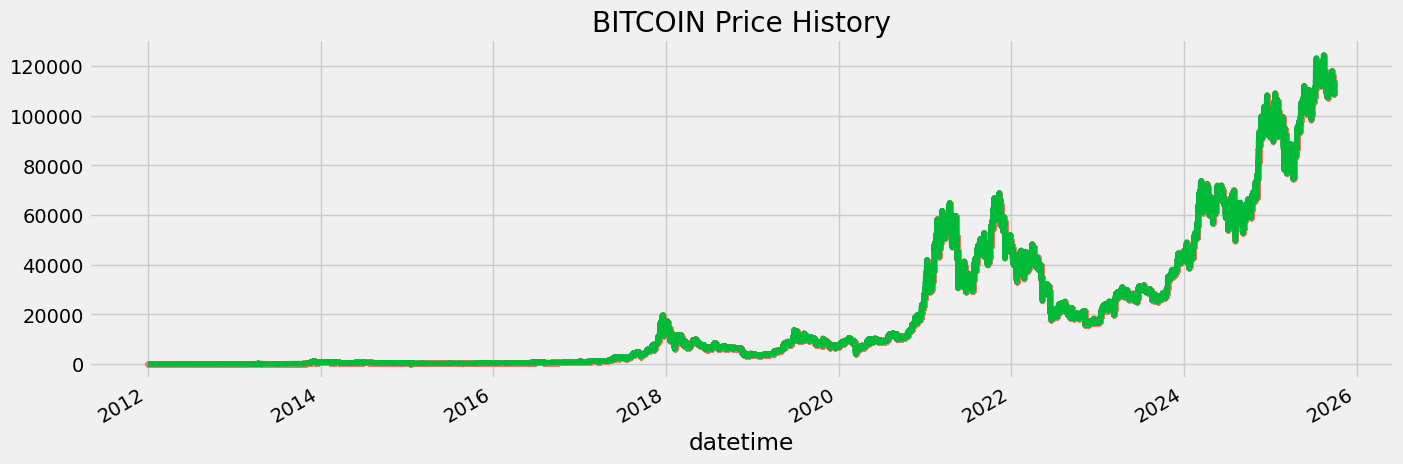

In [9]:
## Vizualising the BTC pricing
df_copy['Open'].plot(style='.', figsize=(15,5), color=color_pal[0], title='BITCOIN Price History')
df_copy['Close'].plot(style='-', figsize=(15,5), color=color_pal[3])
plt.show()

In [10]:
## Data Preprocessing
# Taking 'datetime' & 'Close' column to create a series grouping closing price for each days
df['date'] = pd.to_datetime(df['Timestamp'],unit='s').dt.date
grouped_df = df.groupby('date')
grouped_df = grouped_df['Close'].mean()
grouped_df

date
2012-01-01         4.645697
2012-01-02         4.975000
2012-01-03         5.085500
2012-01-04         5.170396
2012-01-05         5.954361
                  ...      
2025-09-23    112567.609722
2025-09-24    112967.899306
2025-09-25    111217.589583
2025-09-26    109444.711806
2025-09-27    109481.984701
Name: Close, Length: 5019, dtype: float64

In [11]:
# Converting string to a date object to match the index type
# Split Data: Train & Test
grouped_df.index = pd.to_datetime(grouped_df.index)

split_date = '2018-06-30'

data_train = grouped_df.loc[grouped_df.index <= split_date].copy()
data_test = grouped_df.loc[grouped_df.index > split_date].copy()

In [13]:
## Creating and reshaping the training set
training_set = data_train.values
training_set = np.reshape(training_set, (len(training_set), 1))

In [14]:
## Scaling the Training set with MinMaxScaler and spliting to X_train & y_train
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

##
training_set = scaler.fit_transform(training_set)
X_train = training_set[0:len(training_set)-1]
X_train = np.reshape(X_train, (len(X_train), 1, 1))
y_train = training_set[1:len(training_set)]

Plotting the BTC Price by Days.


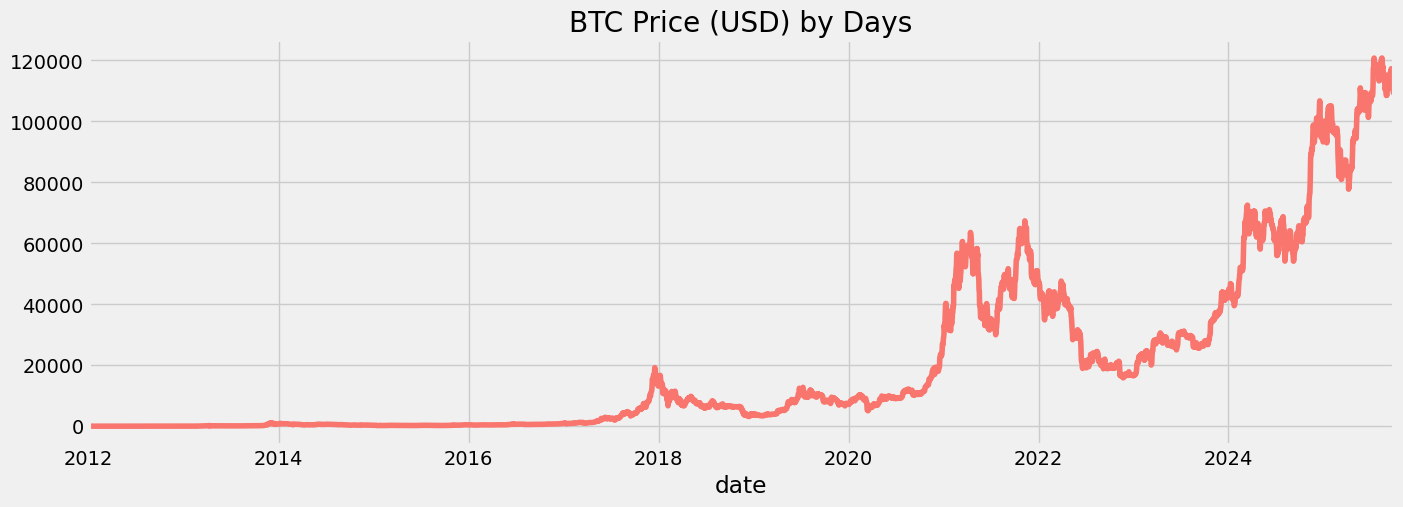

In [15]:
grouped_df.plot(style='', figsize=(15,5), color=color_pal[0], title='BTC Price (USD) by Days')
print('Plotting the BTC Price by Days.')
plt.show()

Plotting the Train vs Test set.


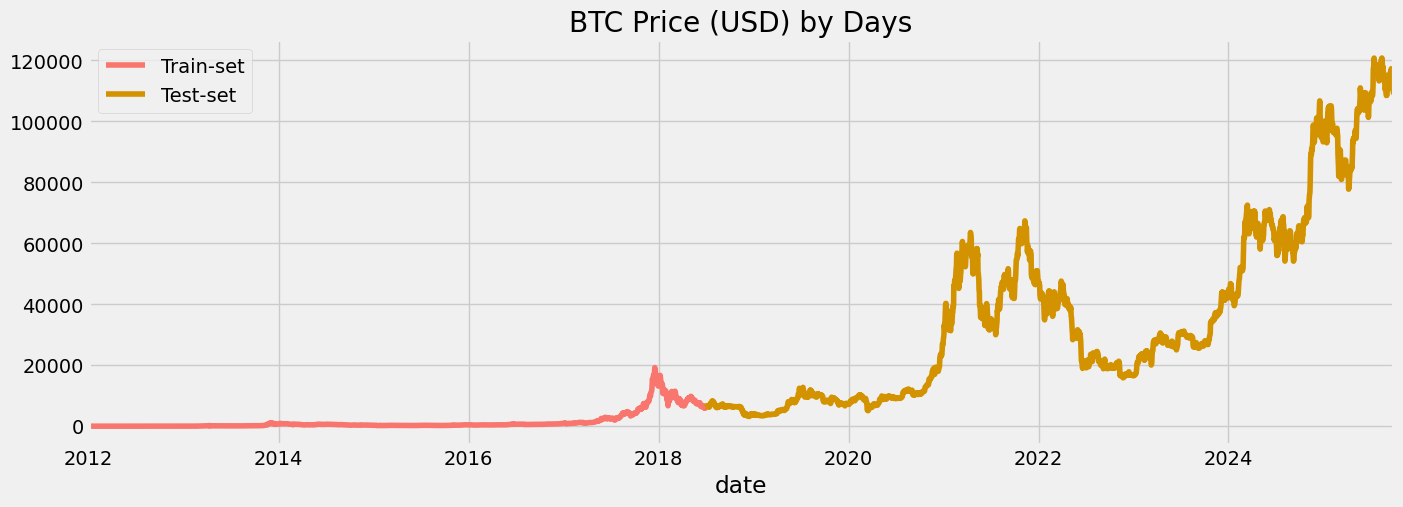

In [16]:
f, ax = plt.subplots(1, figsize=(15, 5))

# Plot training data
data_train.plot(ax=ax, 
                color=color_pal[0], 
                label='Train-set', 
                title='BTC Price (USD) by Days')

# Plot testing data
data_test.plot(ax=ax, 
               color=color_pal[1], 
               label='Test-set')

# Call legend once to display both labels
ax.legend(['Train-set', 'Test-set'])

print('Plotting the Train vs Test set.')
plt.show()

## Fitting SimpleRNN Model

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout, Flatten

regressor=Sequential()
#first RNN layer
regressor.add(SimpleRNN(128,activation="relu",return_sequences=True,input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.25))
#second RNN layer
regressor.add(SimpleRNN(256,activation="relu",return_sequences=True))
regressor.add(Dropout(0.25))
#third RNN layer
regressor.add(SimpleRNN(512,activation="relu",return_sequences=True))
regressor.add(Dropout(0.35))
#fourth RNN layer
regressor.add(SimpleRNN(256,activation="relu",return_sequences=True))
regressor.add(Dropout(0.25))
#fifth RNN layer
regressor.add(SimpleRNN(128,activation="relu",return_sequences=True))
regressor.add(Dropout(0.25))
#convert the matrix to 1-line
regressor.add(Flatten())
#output layer
regressor.add(Dense(1))

regressor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 1, 128)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 1, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 1, 512)         │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 1, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 1, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 755,201 (2.88 MB)

 Trainable params: 755,201 (2.88 MB)

 Non-trainable params: 0 (0.00 B)

Here is a breakdown of what is happening in this model:

### 1. The Input Layer and Shape

* **`input_shape=(1, 1)`**: This is the most critical part of your model. It tells the RNN that each input sample consists of **1 time step** with **1 feature**.
* *Note:* Usually, RNNs are used for sequences (like 10 or 60 time steps). By setting this to `(1, 1)`, you are essentially treating the RNN like a standard Dense network that only looks at one point in time.



### 2. The "Stacked" Architecture

You have 5 layers of SimpleRNNs. This is called "Deep RNN" or "Stacked RNN."

* **`return_sequences=True`**: In layers 1 through 5, this is mandatory because you are stacking them. It tells the layer to pass the entire sequence (all time steps) to the next layer. Without this, the second layer wouldn't receive the data format it needs.
* **Increasing/Decreasing Units**: You start with 128 units, peak at 512 in the middle, and then bottleneck back down to 128. This creates a "diamond" shape, which is sometimes used to force the model to learn complex high-dimensional representations before condensing them.

### 3. Activation Function: `ReLU`

* You chose `activation="relu"`.
* **The Risk:** In SimpleRNNs, `ReLU` can be dangerous because RNNs involve repeated matrix multiplication. If weights are , the values can grow exponentially (Exploding Gradient), leading to `NaN` errors.
* **The Benefit:** If the model is stable, `ReLU` trains faster than `tanh` and helps avoid the "vanishing gradient" problem.

---

### 4. Dropout Layers

* Between every RNN layer, you have `Dropout` (ranging from 0.25 to 0.35).
* During training, this randomly "turns off" 25-35% of the neurons. This forces the model to not rely on any single connection, effectively preventing **overfitting**.

### 5. Transition to Output: `Flatten()`

* **`Flatten()`**: This takes the 3D output of the final RNN layer and squashes it into a 1D vector (a long list of numbers).
* **`Dense(1)`**: This is your prediction layer. Since it's for regression (predicting a price), it produces a single continuous numerical value.

---

### Summary of the Model Summary

When you run `regressor.summary()`, you will see:

1. **Total Parameters**: This will be quite high because of the 512-unit layer and the 5 stacked layers.
2. **Output Shapes**: You will see shapes like `(None, 1, 128)`. The `None` is the batch size, `1` is the time step, and `128` is the number of neurons.

In [19]:
regressor.compile(optimizer="adam", loss="mean_squared_error", metrics=['mae'])
regressor.fit(X_train, y_train, epochs=100, batch_size=50,verbose=1)

Epoch 1/100


2026-01-16 11:04:11.701223: I external/local_xla/xla/service/service.cc:163] XLA service 0x45bf72b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-16 11:04:11.701236: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-01-16 11:04:11.766219: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-16 11:04:12.107030: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0088 - mae: 0.0479 

I0000 00:00:1768541654.029418    5661 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0040 - mae: 0.0323
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021 - mae: 0.0234
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - mae: 0.0214
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - mae: 0.0186
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 - mae: 0.0186
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - mae: 0.0177
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 - mae: 0.0187
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.4806e-04 - mae: 0.0158
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010 - mae: 0.0152    
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - mae: 0.0162    
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010 - mae: 0.0170    
Epoch 12/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010 - mae: 0.0175
Epoch 13/100
48/48 ━━━━━━━━━━━━━

In [20]:
# Making the predictions
testing_set = data_test.values
inputs = np.reshape(testing_set, (len(testing_set), 1))
inputs = scaler.transform(inputs)
inputs = np.reshape(inputs, (len(inputs), 1, 1))
predicted_price_SRnn = regressor.predict(inputs)
predicted_price_SRnn = scaler.inverse_transform(predicted_price_SRnn)

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [21]:
## Creating Dataset to add predicted value
df_all = pd.DataFrame()
df_all['original_price'] = grouped_df.loc[grouped_df.index > split_date].copy()
df_all['predicted_price_rnn'] = predicted_price_SRnn

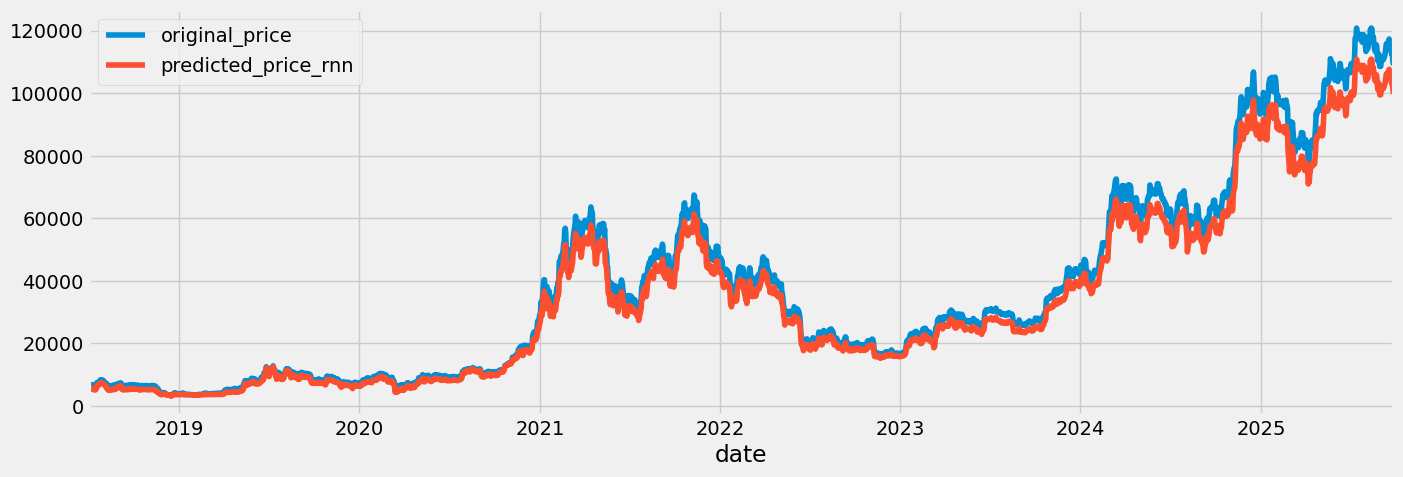

In [22]:
df_all.plot(figsize=(15, 5))
plt.show()

## Fitting LSTM Model

In [132]:
from tensorflow.keras.layers import LSTM

regressor_lstm = Sequential()

regressor_lstm.add(LSTM(256,return_sequences=True,input_shape=(X_train.shape[1],1)))
regressor_lstm.add(Dropout(0.35))
regressor_lstm.add(Dense(256,activation="relu"))
regressor_lstm.add(Dropout(0.25))
regressor_lstm.add(Dense(128,activation="relu"))
regressor_lstm.add(Dense(96,activation="relu"))
regressor_lstm.add(Dense(48,activation="relu"))
regressor_lstm.add(Dense(16, activation="relu"))
regressor_lstm.add(Dense(1))

regressor_lstm.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 1, 256)         │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1, 256)         │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1, 96)          │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 1, 48)          │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 1, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 1, 1)           │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,721 (1.45 MB)

 Trainable params: 380,721 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [133]:
## Compile and fit the model
regressor_lstm.compile(optimizer="adam", loss="mean_squared_error", metrics=['mae'])
regressor_lstm.fit(X_train, y_train, epochs=100, batch_size=32,verbose=1)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - mae: 0.0382
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7043e-04 - mae: 0.0111
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7037e-04 - mae: 0.0126
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2562e-04 - mae: 0.0148
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5461e-04 - mae: 0.0162
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2340e-04 - mae: 0.0095
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5447e-04 - mae: 0.0126
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.2375e-04 - mae: 0.0120
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0499e-04 - mae: 0.0122
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5911e-04 - mae: 0.0090
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7596e-04 - mae: 0.0115
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3792e-04 - mae: 

In [134]:
## Predicting with LSTM model
predicted_price_lstm = regressor_lstm.predict(inputs)
predicted_price_lstm = scaler.inverse_transform(predicted_price_lstm.reshape(-1,1))
df_all['predicted_price_lstm'] = predicted_price_lstm

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [137]:
## Checking the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM
print("Checking the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM:")
df_all

Checking the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM:


,original_price,predicted_price_rnn,predicted_price_lstm
date,,,
2018-07-01,6347.841681,5113.929199,6491.897949
2018-07-02,6409.252000,5169.769043,6548.433105
2018-07-03,6605.425326,5385.451660,6708.029785
2018-07-04,6556.878479,5326.633789,6671.610352
2018-07-05,6604.869944,5384.770020,6707.605957
...,...,...,...
2025-09-23,112567.609722,103196.257812,111658.820312
2025-09-24,112967.899306,103568.726562,112062.867188
2025-09-25,111217.589583,101940.875000,110293.750000


Plotting the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM:


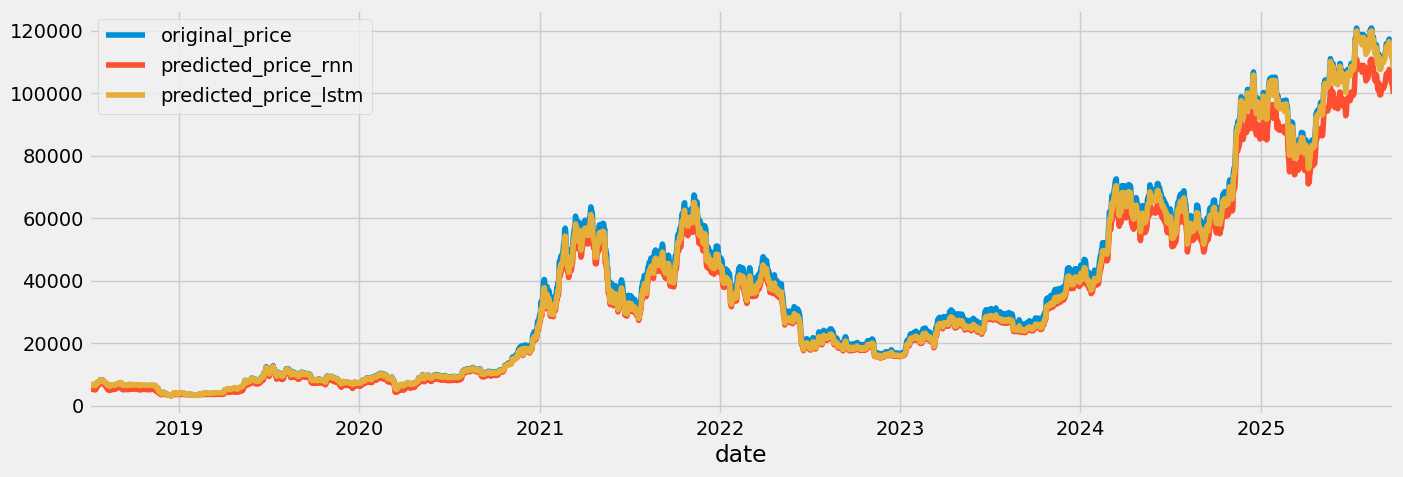

In [139]:
df_all.plot(figsize=(15, 5))
print("Plotting the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM:")
plt.show()

## Performing AD Fuller test BTC Price Data, before fitting ARIMA model

In [141]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Result: Data is Stationary (Ready for ARIMA)")
    else:
        print("Result: Data is Non-Stationary (Needs Differencing)")

# Run it on your training data
check_stationarity(data_train)

ADF Statistic: -1.7010
p-value: 0.4306
Result: Data is Non-Stationary (Needs Differencing)


In [142]:
## Performing Differencing
# Create a differenced version of the data
data_diff = data_train.diff().dropna()

# Check stationarity again
check_stationarity(data_diff)

ADF Statistic: -8.9018
p-value: 0.0000
Result: Data is Stationary (Ready for ARIMA)


In [173]:
## Importing Auto-ARIMA to determine p,d,q
import pmdarima as pm

# Automatically find the best p, d, q
auto_model = pm.auto_arima(data_train, seasonal=False)
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2373
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -15496.324
Date:                Fri, 16 Jan 2026   AIC                          31000.648
Time:                        12:38:38   BIC                          31023.734
Sample:                    01-01-2012   HQIC                         31009.052
                         - 06-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8890      0.010    -91.366      0.000      -0.908      -0.870
ma.L1          1.1266      0.010    108.459      0.000       1.106       1.147
ma.L2          0.2582      0.005     51.368      0.0

In [174]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fitting the model using the (p, d, q) found by pmdarima
# Order = (1, 1, 2)
model = SARIMAX(data_train, 
                order=(1, 1, 2), 
                enforce_stationarity=False, 
                enforce_invertibility=False)

# Fit the model
sarimax_results = model.fit(disp=False)

# Generate Forecast for the duration of the test set
forecast_object = sarimax_results.get_forecast(steps=len(data_test))
forecast_mean = forecast_object.summary_frame()['mean']
conf_int = forecast_object.summary_frame()[['mean_ci_lower', 'mean_ci_upper']]

# Print Summary to verify it matches your report
print(sarimax_results.summary())

/home/prashant/.conda/envs/deeplearning/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/prashant/.conda/envs/deeplearning/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2373
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -15478.701
Date:                Fri, 16 Jan 2026   AIC                          30965.401
Time:                        12:38:59   BIC                          30988.482
Sample:                    01-01-2012   HQIC                         30973.804
                         - 06-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8867      0.010    -88.467      0.000      -0.906      -0.867
ma.L1          1.1242      0.011    105.222      0.000       1.103       1.145
ma.L2          0.2581      0.005     50.696      0.0

                 Actual    Predicted
date                                
2018-07-01  6347.841681  6416.420507
2018-07-02  6409.252000  6447.087921
2018-07-03  6605.425326  6419.894297
2018-07-04  6556.878479  6444.007618
2018-07-05  6604.869944  6422.625685


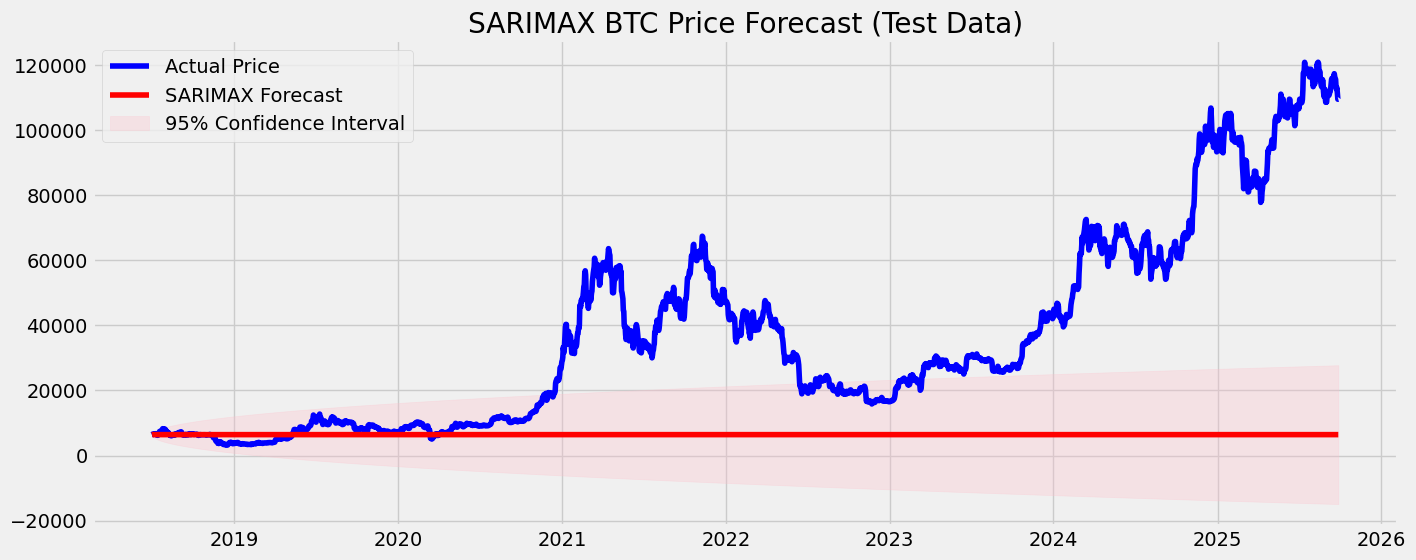

In [175]:
# Create a summary DataFrame
performance_df = pd.DataFrame({
    'Actual': data_test,
    'Predicted': forecast_mean
}, index=data_test.index)

# Preview the results
print(performance_df.head())

# Visualizing the Forecast

plt.figure(figsize=(15, 6))

# Plot Actual Test Data
plt.plot(data_test.index, data_test, label='Actual Price', color='blue')

# Plot Forecasted Mean
plt.plot(performance_df.index, performance_df['Predicted'], label='SARIMAX Forecast', color='red')

# Plot Confidence Intervals (Lower and Upper bounds)
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('SARIMAX BTC Price Forecast (Test Data)')
plt.legend()
plt.show()

Plotting the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM vs. Predicted_Price_SARIMAX:


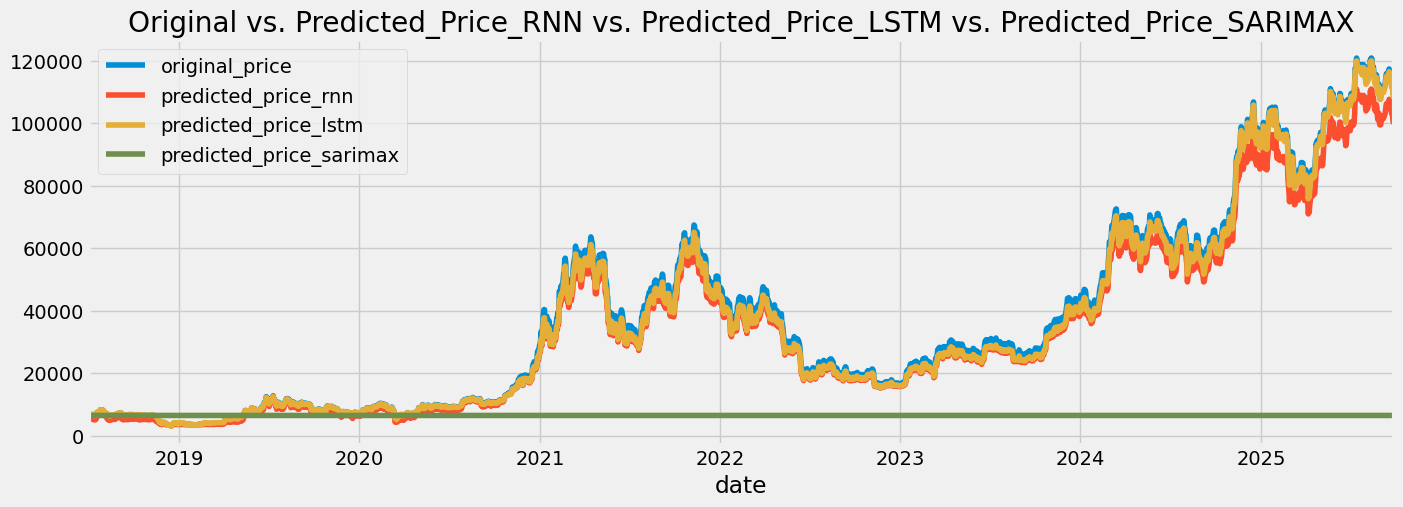

In [176]:
## Adding the predicted data to 'df_all' database
df_all['predicted_price_sarimax'] = performance_df['Predicted']

## Ploting the result
df_all.plot(figsize=(15, 5), title="Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM vs. Predicted_Price_SARIMAX")
print("Plotting the Original vs. Predicted_Price_RNN vs. Predicted_Price_LSTM vs. Predicted_Price_SARIMAX:")
plt.show()

In [178]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- SARIMAX Metrics ---
# 'forecasted_values' is the predicted_mean from your SARIMAX model
sarimax_rmse = np.sqrt(mean_squared_error(data_test, forecasted_values))
sarimax_mae = mean_absolute_error(data_test, forecasted_values)

# --- SimpleRNN & LSTM Metrics ---
# 'predicted_price_SRnn' is the inverse_transformed result from your RNN
rnn_rmse = np.sqrt(mean_squared_error(data_test, predicted_price_SRnn))
rnn_mae = mean_absolute_error(data_test, predicted_price_SRnn)
lstm_rmse = np.sqrt(mean_squared_error(data_test, predicted_price_lstm))
lstm_mae = mean_absolute_error(data_test, predicted_price_lstm)

# --- Results Summary ---
print("      Metric | SARIMAX | SimpleRNN | LSTM")
print(f"-------------|---------|----------------")
print(f"        RMSE | {sarimax_rmse:7.2f} | {rnn_rmse:10.2f} | {lstm_rmse:10.2f}")
print(f"         MAE | {sarimax_mae:7.2f} | {rnn_mae:10.2f} | {lstm_mae:10.2f}")

      Metric | SARIMAX | SimpleRNN | LSTM
-------------|---------|----------------
        RMSE | 47999.17 |    4213.87 |    1680.97
         MAE | 36891.63 |    3307.08 |    1347.88


In [177]:
print("Final BTC Price Prediction dataset with SimpleRNN, LSTM & SARIMAX")
df_all

,original_price,predicted_price_rnn,predicted_price_lstm,predicted_price_sarimax
date,,,,
2018-07-01,6347.841681,5113.929199,6491.897949,6416.420507
2018-07-02,6409.252000,5169.769043,6548.433105,6447.087921
2018-07-03,6605.425326,5385.451660,6708.029785,6419.894297
2018-07-04,6556.878479,5326.633789,6671.610352,6444.007618
2018-07-05,6604.869944,5384.770020,6707.605957,6422.625685
...,...,...,...,...
2025-09-23,112567.609722,103196.257812,111658.820312,6432.674800
2025-09-24,112967.899306,103568.726562,112062.867188,6432.674800
2025-09-25,111217.589583,101940.875000,110293.750000,6432.674800


---

### 1. The Performance Gap: Why SARIMAX "Failed"

The most striking thing here is that **SARIMAX has a massive error** (RMSE: 47,999) compared to the others.

* **Linear Limitations:** SARIMAX is a linear model. BTC prices are famously non-linear and volatile. If the price moved significantly out of the range seen in the training data (2012–2018), SARIMAX often "breaks" and predicts a flat line or a wildly incorrect trend.
* **The "Lag" Effect:** Statistical models often struggle when the "scale" of the data changes. Since BTC went from  to  in your training window, the SARIMAX model's variance became too high to manage without sophisticated differencing or logging.

### 2. SimpleRNN vs. LSTM: The "Memory" Advantage

The **LSTM is the clear winner** here, with an RMSE of 1,680 vs. the SimpleRNN’s 4,213.

* **Vanishing Gradients:** SimpleRNNs have "short-term memory." They often forget what happened at the start of a sequence by the time they reach the end.
* **Long-Term Dependencies:** LSTMs use "gates" to decide what information to keep and what to forget. In BTC prices, certain patterns (like a 4-year cycle or a 60-day momentum) are better captured by LSTMs because they don't "forget" the earlier parts of the window as easily.

---

### 3. Understanding the Metric Types

#### **RMSE (Root Mean Squared Error)**

* **SARIMAX:** 47,999.17
* **LSTM:** 1,680.97
* **What it tells:** RMSE penalizes **large errors** more than small ones. Because the error is squared before being averaged, one or two "huge misses" (like missing a  crash) will make this number explode.
* **Conclusion:** The high RMSE in SARIMAX suggests it had some **catastrophic failures** where it was off by an enormous margin. The LSTM stayed much "closer" to the actual price even during spikes.

#### **MAE (Mean Absolute Error)**

* **SARIMAX:** 36,891.63
* **LSTM:** 1,347.88
* **What it tells:** This is the average "offness."
* **Conclusion:** On average, your LSTM is off by about **** per prediction. Given the high price of BTC, an error of  is actually quite respectable for a base model.

---

### 4. Summary Table of Insights

| Model | Status | Verdict |
| --- | --- | --- |
| **SARIMAX** | **Underfitting** | Too simple for the complexity of BTC. The error is 30x higher than LSTM. |
| **SimpleRNN** | **Decent** | Captured the trend but likely struggled with the "noise" and long-term memory. |
| **LSTM** | **Best Fit** | Handled the volatility and sequence patterns best. This is your "Production" model. |

### Why is the error still  for LSTM?

In financial forecasting, a "perfect" 0 error is impossible (and usually means you are cheating by looking at the future). An error of  means the model is picking up the **trend** correctly, but it cannot predict the exact "random walk" of daily price movements.

In [183]:
## Saving the LSTM model and the predicted dataset for future evalution and Versioning
regressor_lstm.save("BTC_price_LSTM_Model.keras")

# Add a column for the Residuals/Error
df_all['LSTM_Error'] = df_all['original_price'] - df_all['predicted_price_lstm']
df_all.to_csv("BTC_Price_Prediction.csv", index=True)